In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('05_Student_Performance.csv')

In [3]:
df.head(3)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 493.2 KB


In [5]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [6]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(127)

In [8]:
# Check unique values
for col in df.columns:
    print(col, ":", df[col].nunique())

Hours Studied : 9
Previous Scores : 60
Extracurricular Activities : 2
Sleep Hours : 6
Sample Question Papers Practiced : 10
Performance Index : 91


In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   str    
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), str(1)
memory usage: 565.2 KB


In [12]:
df.shape

(9873, 6)

In [13]:
df.corr(numeric_only=True
        )

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.007975,0.008719,0.915135
Sleep Hours,0.002131,0.007975,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.050352,0.043436,1.000000


In [14]:
df.corr(numeric_only=True)["Performance Index"].sort_values(ascending=False)

Performance Index                   1.000000
Previous Scores                     0.915135
Hours Studied                       0.375332
Sleep Hours                         0.050352
Sample Question Papers Practiced    0.043436
Name: Performance Index, dtype: float64

<Axes: >

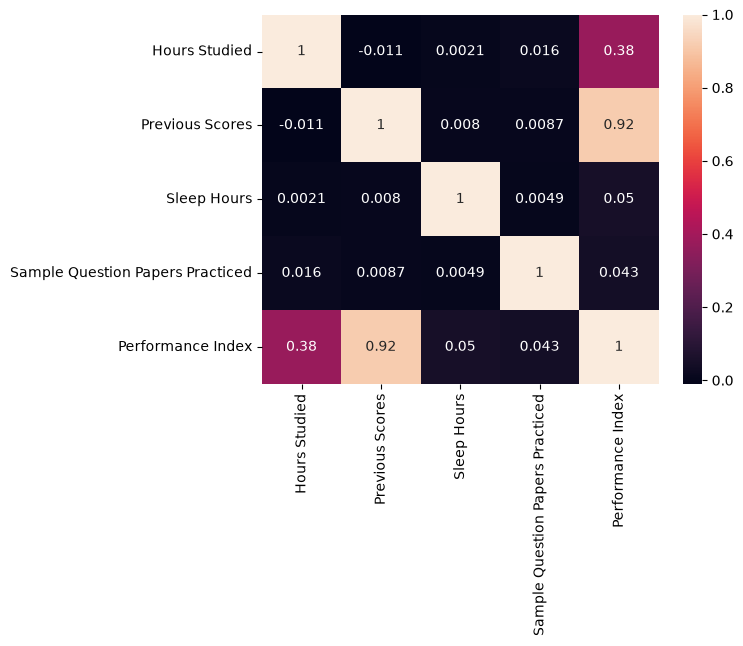

In [15]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [16]:
df = df.rename(columns={'Sample Question Papers Practiced':'Papers Practiced'})

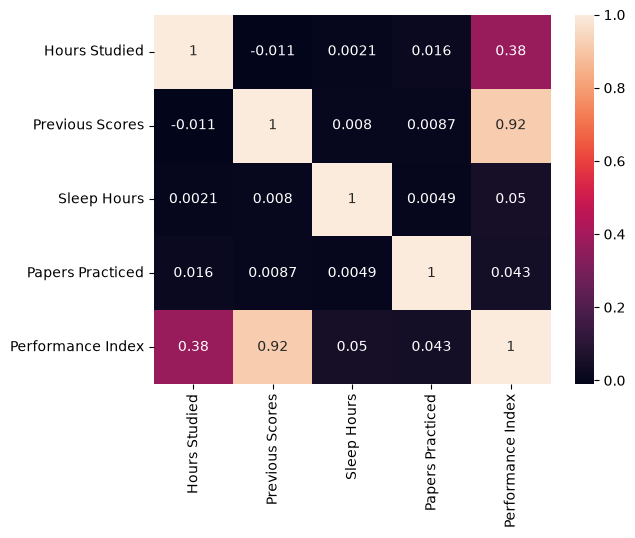

In [17]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [18]:
# Feature & Target Selection + Train/Test Split
X = df.drop('Performance Index',axis=1)
y = df['Performance Index']

In [19]:
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Papers Practiced
0,7,99,Yes,9,1
1,4,82,No,4,2
2,8,51,Yes,7,2
3,5,52,Yes,5,2
4,7,75,No,8,5
...,...,...,...,...,...
9995,1,49,Yes,4,2
9996,7,64,Yes,8,5
9997,6,83,Yes,8,5
9998,9,97,Yes,7,0


In [20]:
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 9873, dtype: float64

In [21]:
# Train/Test Split

from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size=0.2,
                                                       random_state=42)

In [22]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(7898, 5)
(7898,)
(1975, 5)
(1975,)


In [23]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
from sklearn.preprocessing import OneHotEncoder

# Encoder
OHE = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Training data par fit + transform
X_train_encoded = OHE.fit_transform(
    X_train[["Extracurricular Activities"]]
)

# Testing data par only transform
X_test_encoded = OHE.transform(
    X_test[["Extracurricular Activities"]]
)

In [29]:
X_train = X_train.drop("Extracurricular Activities", axis=1)
X_test = X_test.drop("Extracurricular Activities", axis=1)

X_train = X_train.join(
    pd.DataFrame(
        X_train_encoded,
        columns=OHE.get_feature_names_out(["Extracurricular Activities"]),
        index=X_train.index
    )
)

X_test = X_test.join(
    pd.DataFrame(
        X_test_encoded,
        columns=OHE.get_feature_names_out(["Extracurricular Activities"]),
        index=X_test.index
    )
)

In [30]:
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 2.85, 1.02, 0.47, 0.19,-0.29, 0.29]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Hours Studied','Previous Scores','Sleep Hours','Papers Practiced', 'Extracurricular Activities_No','Extracurricular Activities_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.69
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [31]:
regressor.coef_

array([ 2.8510219 ,  1.01843034,  0.47207329,  0.18870366, -0.28691148,
        0.28691148])

In [32]:
regressor.intercept_

np.float64(-33.694413012665734)

In [33]:
y_pred = regressor.predict(X_test)

In [34]:
y_pred

array([46.48001281, 80.2853795 , 61.06518835, ..., 77.08443628,
       86.24676576, 35.8793377 ], shape=(1975,))

In [35]:
y_test

6099    47.0
106     76.0
9265    62.0
4707    23.0
2155    76.0
        ... 
8732    19.0
3112    39.0
5297    77.0
6116    88.0
5088    34.0
Name: Performance Index, Length: 1975, dtype: float64

In [36]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [37]:
print("MAE" , mean_absolute_error(y_pred,y_test))
print("MSE" , mean_squared_error(y_pred,y_test))
print("RMSE" , np.sqrt(mean_squared_error(y_pred,y_test)))
print("R2 Score ", r2_score(y_pred,y_test))

MAE 1.6469703984255564
MSE 4.305900938538473
RMSE 2.075066490148803
R2 Score  0.9882856957337527


In [38]:
ac = pd.DataFrame({'actual:':y_test,"predict":y_pred})

In [39]:
ac

,actual:,predict
6099,47.0,46.480013
106,76.0,80.285379
9265,62.0,61.065188
4707,23.0,22.706315
2155,76.0,74.836868
...,...,...
8732,19.0,18.277835
3112,39.0,40.310084
5297,77.0,77.084436
6116,88.0,86.246766


In [40]:
ac['Error'] = abs(ac['actual:'] - ac['predict'])

In [41]:
ac.head(10)

,actual:,predict,Error
6099,47.0,46.480013,0.519987
106,76.0,80.285379,4.285379
9265,62.0,61.065188,0.934812
4707,23.0,22.706315,0.293685
2155,76.0,74.836868,1.163132
6594,83.0,84.194968,1.194968
9438,60.0,61.993141,1.993141
8905,51.0,50.337443,0.662557
2012,38.0,38.898681,0.898681
568,58.0,55.753202,2.246798


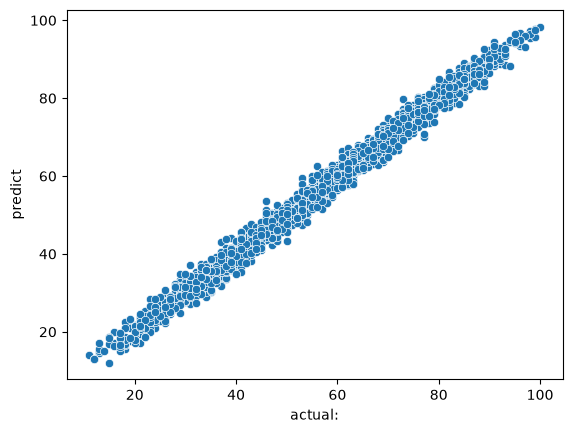

In [43]:
sns.scatterplot(data = ac , x = 'actual:', y = 'predict')
plt.show()

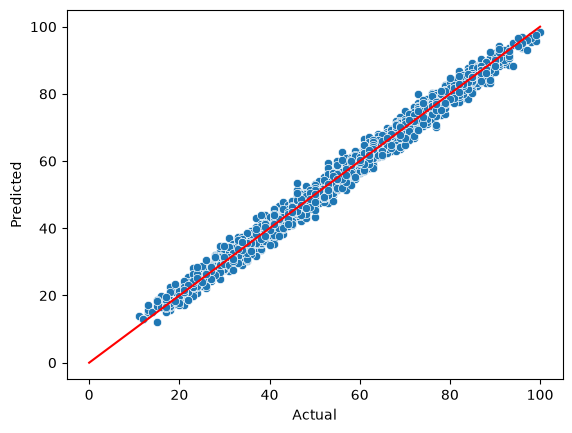

In [47]:
sns.scatterplot(data=ac, x='actual:', y='predict')

plt.plot([0, 100], [0, 100], color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()